# 4428 Project

### 4-18-2026

### Ram Prasad 

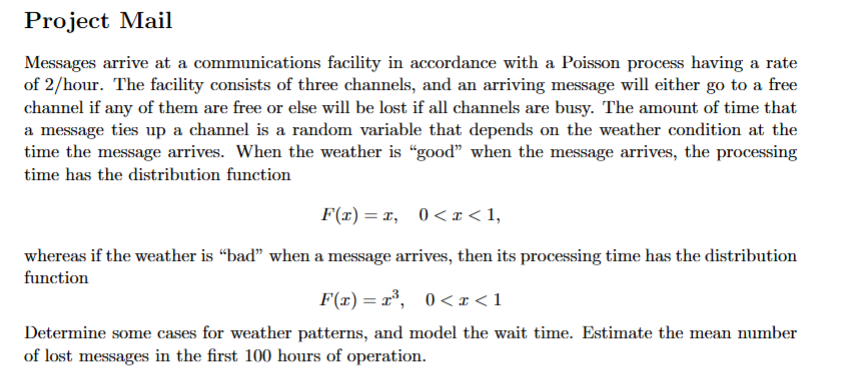

In [1]:
# standard imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

## Setup 

Arrivals are PP(2). 3 parallel channels, message assigned to a channel immediately is at least 1 channel available, lost if all 3 are busy. Service times are weather state contingent. Think of the sequence of events as Arrival → Weather realization → Assign service time → Enter free channel. 

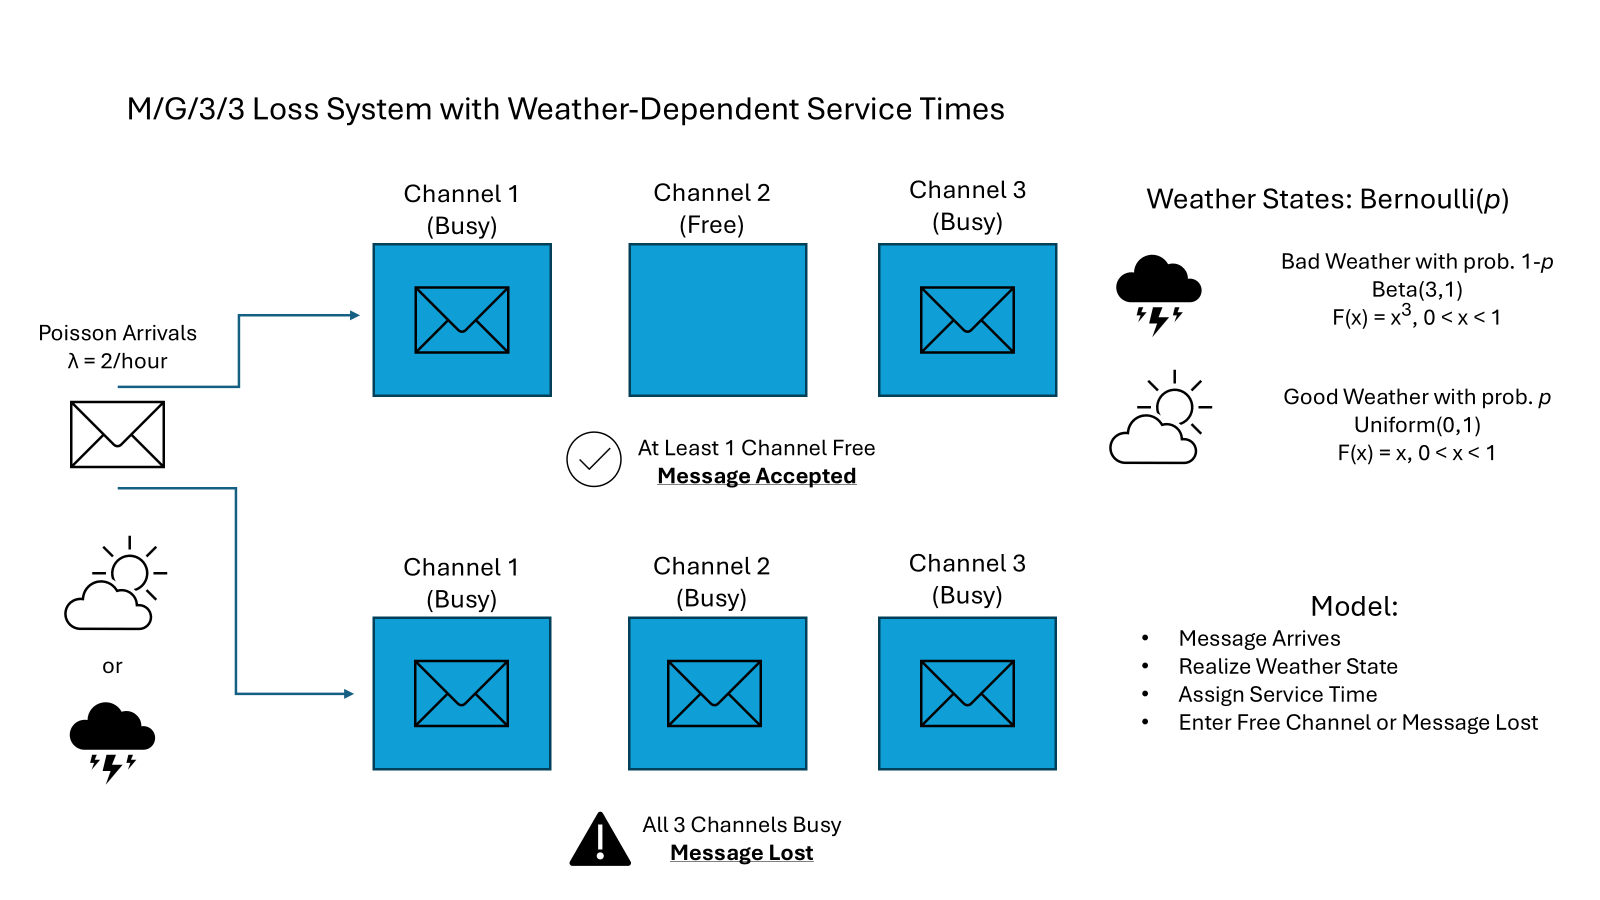

## Preliminaries 

Using Kendall notation, the model is M/G/3/3, meaning a Markov arrival process, general service time distribution, 3 channels, and system capacity of 3. What distinguishes this problem from a generic loss system is the weather randomness and
its effect on service times. There are two weather states. One is good, the other is bad. Assume the distribution of weather states is random, where $p$ is the probability of good weather. Let $W$ be the weather, where

$$
W \sim \text{Bernoulli}(p)
$$

and $W=1$ corresponds to good weather, and $W=0$ corresponds to bad weather, and 

$$
P(W=1)=p ,\quad P(W=0)=1-p.
$$

Conditional on the weather state, the service time $X$ has two distributions, one for good weather (Uniform(0,1), mean $1/2$, variance $1/12$)

$$
F_{G}(x) = x, \quad 0 < x < 1
$$

one for bad weather (Beta(3,1))

$$
F_{B}(x) = x^{3}, \quad 0 < x < 1.
$$

with mean

\begin{align*}
E(B) &= \int_{0}^{1} x (3x^{2}) dx \\
     &= 3\int_{0}^{1} x^{3} dx = \frac{3}{4}. \\
\end{align*}

In the bad weather state, the expected service time (0.75) is greater than that of the good weather state (0.5). 

The unconditional service time $X$ is a mixture (not a linear combination) of two distributions. I solve for the mixture distribution using the law of total probability

\begin{align*}
P(X \le x) &= P(X \le x \mid G)P(G) +  P(X \le x \mid B)P(B) \\
           &= P(X \le x \mid G)p +  P(X \le x \mid B)(1-p) \\
           &= px + (1-p)x^{3}.
\end{align*}

In the equation above, $p$ is a parameter. It is deterministic, so it is straightforward to compute the PDF and moments. Differentiating the CDF gives the PDF

\begin{align*}
f_X(x) &=\frac{d}{dx}F_X(x) \\
       &= p+3(1-p)x^2, \quad 0 < x < 1.
\end{align*}

I compute the expected value

\begin{align*}
E(X) &= \int_{0}^{1} x(p+3(1-p)x^2) dx \\
     &= p \left[ \frac{1}{2}x^{2} \right]_{x=0}^{x=1} + 3(1-p)\left[ \frac{1}{4}x^{4} \right]_{x=0}^{x=1} \\
     &= \frac{p}{2} + 3(1-p)\frac{1}{4} \\
     &= \frac{2p + 3 - 3p}{4} \\
     &= \frac{3 - p}{4}.
\end{align*}

Another way to get the expected value is using the law of total expectation. 

\begin{align*}
E[X] &= E[X \mid W=1]P(W=1) + E[X \mid W=0]P(W=0) \\
     &= \frac{1}{2}p + \frac{3}{4}(1-p) \\
     &= \frac{3 - p}{4} 
\end{align*}

For the variance, 

\begin{align*}
E(X^{2}) &= \int_{0}^{1} x^{2}(p+3(1-p)x^2) dx \\
         &= p \left[ \frac{1}{3}x^{3} \right]_{x=0}^{x=1} + 3(1-p)\left[ \frac{1}{5}x^{5} \right]_{x=0}^{x=1} \\
         &= \frac{p}{3} + \frac{3(1-p)}{5} \\
         &= \frac{5p + 9(1-p)}{15} \\
         &= \frac{9-4p}{15}
\end{align*}

Thus

\begin{align*}
\text{Var}(X) &= E[X^2] - \bigl(E[X]\bigr)^2 \\
              &= \frac{9-4p}{15} - \left(\frac{3-p}{4}\right)^2 \\
              &= \frac{9-4p}{15} - \frac{9-6p+p^{2}}{16} \\
              &= \frac{3}{5} - \frac{4p}{15} -\frac{9}{16} + \frac{3p}{8} - \frac{p^{2}}{16} \\
              &= \frac{48 - 45}{80} + \frac{45p - 32p}{120} - \frac{p^{2}}{16} \\
              &= \frac{3}{80} + \frac{13}{120}p - \frac{1}{16}p^2.
\end{align*}


I check my results using simulation, first drawing a Bernoulli vector of 1s and 0s, second drawing from a uniform and beta distribution (using inverse CDF sampling) for 1 and 0, respectively, and third computing the sample mean and variance of the drawn values. 

In [2]:
def sim_service_time(p, n=1000):
    """
    Simulate service times from a mixture 
    of Uniform(0,1) with prob. p and Beta(3,1)
    with prob. 1-p. 
    Args:
    -----
        p (float): mixture probability
        n (int): number of draws
    Returns:
    --------
        X (array): vector of drawn service times
    """
    # Bernoulli draws (1 = good weather, 0 = bad weather)
    W = np.random.binomial(1, p, size=n)
    
    # uniform draws
    U = np.random.uniform(0, 1, size=n)
    
    # allocate output
    X = np.empty(n)
    
    # good weather is Uniform(0,1)
    X[W == 1] = U[W == 1]
    
    # bad weather is Beta(3,1) via inverse transform
    X[W == 0] = U[W == 0]**(1/3)
    
    return X
    
# df for grid results
sim_df = pd.DataFrame()
sim_df["p"] = np.linspace(0.0,1.0,21)
sim_df["Analytic E(X)"] = sim_df["p"].apply(lambda p: (3-p)/4)
sim_df["Analytic Var(X)"] = sim_df["p"].apply(lambda p: 3/80 + (13/120)*p - (1/16)*(p**2))

# simulate over grid
sim_moments = []
for p in sim_df["p"]:
    x = sim_service_time(p, n=10000)
    sim_moments.append((np.round(np.mean(x),3), np.round(np.var(x),5)))
sim_df["Simulation Moments"] = sim_moments

# check results
display(sim_df)

,p,Analytic E(X),Analytic Var(X),Simulation Moments
0,0.00,0.7500,0.037500,"(0.75, 0.03639)"
1,0.05,0.7375,0.042760,"(0.737, 0.04331)"
2,0.10,0.7250,0.047708,"(0.72, 0.05029)"
3,0.15,0.7125,0.052344,"(0.709, 0.05327)"
4,0.20,0.7000,0.056667,"(0.701, 0.05621)"
5,0.25,0.6875,0.060677,"(0.689, 0.061)"
6,0.30,0.6750,0.064375,"(0.675, 0.06473)"
7,0.35,0.6625,0.067760,"(0.662, 0.06827)"
8,0.40,0.6500,0.070833,"(0.651, 0.07083)"
9,0.45,0.6375,0.073594,"(0.641, 0.0731)"


Simulation moments are quite close to analytic mean and variance. Errors are within MC noise. 

## Model

Per Smith et al (2004) and Cheah and MacGregor (1994), the M/G/C/C and M/M/C/C distributions of loss probability are stochastically equivalent. This result is known as Erlang's Insensitivity Property, which states that the steady state probability of $k$ busy servers depends only on the mean of the service time distribution, not on its shape or variance. 

The instructions ask to model the wait time, but in a pure loss system a message is either admitted immediately or lost, thus there is no queue and thus no waiting time in the usual sense. 

The system is defined by the number of messages present. When there are 3 messages already in the mail system, any subsequent messages get lost. 

Let $k=0,1,2,3$. $p_k$ is the probability that there are $k$ messages in the system. Messages arrive at rate $\lambda=2$, service time is mean $(3-p)/4$. Let $a=\lambda E(X)$, then

$$
p_{k} = p_{0}\frac{a^k}{k!} = \frac{a^{k}/k!}{\sum_{j=0}^{3}(a^{j}/j!)}
$$

A message gets lost when there are already 3 messages in the system, and all servers are unavailable. The probability that an individual message gets lost is thus the probability that there are 3 messages in the system at an arbitrary time, which is

$$
p_{3} = \frac{a^{3}/3!}{\sum_{j=0}^{3}(a^{j}/j!)}
$$

which is the Erlang-B formula. Substituting gives

\begin{align*}
P(\text{message lost}) &= p_{3} \\
&= \frac{ \frac{1}{6} \left( \frac{3-p}{2} \right)^{3}  }{ 1 + \frac{3-p}{2} + \frac{1}{2}\left( \frac{3-p}{2} \right)^{2} + \frac{1}{6}\left( \frac{3-p}{2} \right)^{3}} \\
&= \frac{\left(\frac{3-p}{2}\right)^3}{6 + 6\left(\frac{3-p}{2}\right) + 3\left(\frac{3-p}{2}\right)^2 + \left(\frac{3-p}{2}\right)^3} \\
&= \frac{\frac{(3-p)^3}{8}}{6 + 3(3-p) + \frac{3}{4}(3-p)^2 + \frac{(3-p)^3}{8}} \\
&= \frac{(3-p)^3}{48 + 24(3-p) + 6(3-p)^2 + (3-p)^3} \\
&= \frac{27 - 27p + 9p^2 - p^3}{201 - 87p + 15p^2 - p^3}.
\end{align*}

With the probability of a message getting lost in hand, I compute the number of expected messages and then the number of expected messages lost.  

Messages $M(t)$ follow a PP(2) process. For any fixed $t$,
$$
M(t) \sim \mathrm{Poisson}(2t),
$$
with PMF
$$
P(M(t)=k) = \frac{(2t)^k e^{-2t}}{k!}, \quad k=0,1,2,\dots
$$
and moments

\begin{align*}
E(M(t)) &= 2t \\
\text{Var}(M(t)) &= 2t.
\end{align*}

Let $L_{m}(t)$ be the number of messages lost in the interval $[0,t]$. Let $L_i$ be an indicator, which takes the value of 1 if the $i$th message gets lost with probability $p_3$. 

$$
L_{m}(t) = \sum_{i=1}^{M(t)}L_{i}
$$

Using the law of iterated expectation,

\begin{align*}
E(L_{m}(t)) &= E( \sum_{i=1}^{M(t)}L_{i}  )\\
            &= E\left[ E(\sum_{i=1}^{M(t)}L_{i} \mid M(t) = m )  \right] \\
            &= E\left[ M(t)  \right]E\left[ L_i  \right] \\
            &= \lambda t p_{3}.
\end{align*}

Thus

$$
E[L_{m}(t)] = (\lambda t\,) p_3 = 2t\, \left(\frac{a^3/6}{1+a+\frac{a^2}{2}+\frac{a^3}{6}} \right), \qquad a=\frac{3-p}{2}. 
$$

At $t=100$, meaning over the interval $[0,100]$ corresponding to 100 hours, the expected number of messages is 200, and the expected number of lost messages is

$$
200p_{3} = \frac{200(27 - 27p + 9p^2 - p^3)}{201 - 87p + 15p^2 - p^3}.
$$


I consider different cases for weather patterns by fixing $t=100$ for 100 hours, varying $p$, and computing the expected number of lost messages.  

Case 1: Always good weather ($p=1$).

Expected service time is the mean of a Uniform(0,1), thus $E(X)=1/2$ and $a=(3-1)/2=1$, 

$$
p_3
=
\frac{1/6}{1+1+\frac{1}{2}+\frac{1}{6}}
=
\frac{1}{16}.
$$

and 

$$
E[L_m(t)] = 2t\left(\frac{1}{16}\right)=\frac{t}{8}.
$$

thus for $t=100$, $E[L_m(100)] = 12.5$.

Case 2: Always bad weather ($p=0$).

Expected service time is mean of a Beta(3,1), thus $E[X]=\frac{3}{4}$ and $a=\frac{3}{2}$.

$$
p_3
=
\frac{(3/2)^3/6}{1+\frac{3}{2}+\frac{1}{2}(3/2)^2+\frac{1}{6}(3/2)^3}
\approx 0.134328
$$

and 

$$
E[L_m(t)] \approx 2t(0.134328)=0.268656\,t
$$

thus for $t=100$,

$$
E[L_m(100)] \approx 26.87.
$$

Case 3: Good and bad weather equally likely ($p=\frac{1}{2}$).

$$
E[X]
=
\frac{1}{2}\cdot\frac{1}{2}
+
\frac{1}{2}\cdot\frac{3}{4}
=
\frac{5}{8},
$$
and 

$$
a=2\cdot \frac{5}{8}=\frac{5}{4}.
$$

Thus
$$
p_3
=
\frac{(5/4)^3/6}{1+\frac{5}{4}+\frac{1}{2}(5/4)^2+\frac{1}{6}(5/4)^3}
\approx 0.096974.
$$

and

$$
E[L_m(t)] \approx 2t(0.096974)=0.193948\,t
$$

where for $t=100$,
$$
E[L_m(100)] \approx 19.39.
$$

I implement the formulas and evaluate them on a grid for the probability of good weather. 

p=1, P(Msg Lost) = 0.0625, E(Lm(100)) = 12.5
p=0, P(Msg Lost) = 0.13432835820895522, E(Lm(100)) = 26.865671641791046
p=0.5, P(Msg Lost) = 0.09697439875872768, E(Lm(100)) = 19.394879751745535


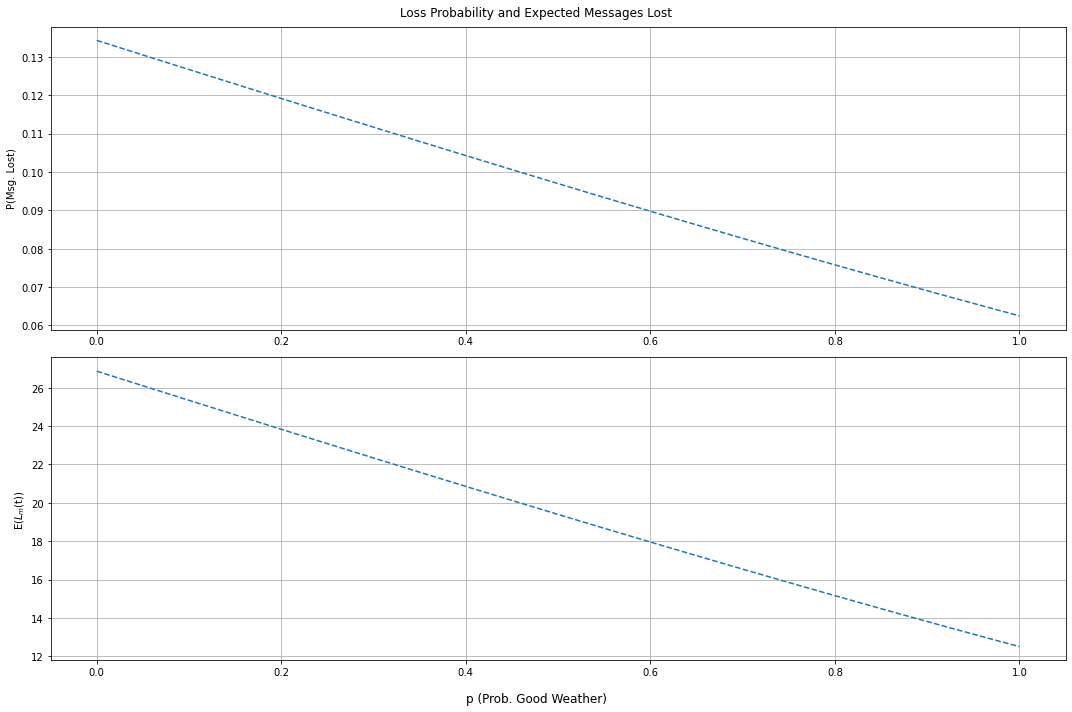

In [3]:
# Erlang-B blocking probability
def erlang_b(k, a):
    """
    Compute Erlang-B blocking probability.
    Args:
    -----
        k (int): number of servers
        a (float): lambda*E[X]
    Returns:
    --------
        (float): blocking probability
    """
    # construct denominator
    denom = 0.0
    for j in range(k + 1):
        denom = denom + (a**j)/math.factorial(j)

    # return blocking probability
    return ((a**k)/math.factorial(k))/denom

# expected number of lost messages
def exp_lmt(p, lam=2, t=100):
    """
    Compute expected number of lost messages. 
    Args:
    -----
        p (float): probability of good weather
        lam (int): rate parameter
        t (float): length of time interval
    Returns:
    --------
        e (float): expected number of lost messages
    See above for formulas. 
    """
    # compute a
    a = lam*(3-p)/4
    
    # compute p_3
    p_3 = erlang_b(3, a)
    
    # return expected lost
    e = lam*t*p_3
    return e

# test functions
for p in [1,0,0.5]:
    print(f"p={p}, P(Msg Lost) = {erlang_b(3, (3-p)/2)}, E(Lm(100)) = {exp_lmt(p, lam=2, t=100)}")
    
    
# evaluate on grid
p_grid = np.linspace(0.0,1.0,100+1)
erlang_grid = [erlang_b(3, (3-p)/2) for p in p_grid]
e_lmt_grid = [exp_lmt(p, lam=2, t=100) for p in p_grid]

# plot
fig, axs = plt.subplots(2,1, figsize=(15,10))
axs[0].plot(p_grid, erlang_grid, linestyle="--")
axs[0].grid()
axs[0].set_ylabel("P(Msg. Lost)")
axs[1].plot(p_grid, e_lmt_grid, linestyle="--")
axs[1].grid()
axs[1].set_ylabel(r"E($L_{m}$(t))")
fig.suptitle("Loss Probability and Expected Messages Lost")
fig.supxlabel("p (Prob. Good Weather)")
plt.tight_layout()
plt.show()

The expected messages lost is linear in the probability of good weather. As the probability of good weather increases, probability of messages lost falls and expected number of messages lost falls (still non-zero for both, even when probability of good weather is 1). This is a very intuitive result. Expected service time is decreasing in p, and lower service times means messages get processed faster, there is less congestion, more servers are available at any one time, and therefore fewer messages lost. 

## Simulation

To verify my analytic results, I perform simulation of paths of the M/G/3/3 loss system over the period [0,t], where again arrivals follow PP(2), the weather state is Bernoulli and service times are state contingent. 

The procedure is as follows:

First, the number of arrivals $M(t)$ is
$$
M(t) \sim \mathrm{Poisson}(2t).
$$

so I generate arrival times $\{T_i\}$ from a Poisson process with rate $\lambda=2$ by sampling interarrival times

$$
T_{i+1} - T_i \sim \mathrm{Exp}(\lambda),
$$
and accumulate until exceeding the time horizon $t$.

Second, maintain a list of departure times corresponding to messages currently being serviced. At each arrival time $T_i$, remove all completed services. The number of busy channels is then the number of jobs such that their departure time is greater than $T_i$. 


Third, at each arrival, generate a Bernoulli random variable

$$
W_i \sim \mathrm{Bernoulli}(p),
$$

where $W_i=1$ corresponds to good weather and $W_i=0$ to bad weather.

Fourth, given the weather state, draw processing time

$$
X_i =
\begin{cases}
U, & W_i = 1, \\
U^{1/3}, & W_i = 0,
\end{cases}
\qquad U \sim \mathrm{Uniform}(0,1).
$$

Fifth, if the system has capacity, meaning if the number of busy channels is <3, the message is accepted and occupies a channel for time $X_i$. Otherwise (3 busy channels), the message gets lost. Set the loss indicator

$$
L_i =
\begin{cases}
1, & \text{if 3 busy channels}, \\
0, & \text{otherwise}.
\end{cases}
$$

Sixth, if the message gets accepted, add the departure time $T_i + X_i$ to the system. If lost, no state change occurs.

For each single simulation path, I compute the following.

The number of lost messages:

$$
L_m(t) = \sum_{i=1}^{M(t)} L_i.
$$

To estimate the loss probability, I compute the fraction of messages lost:

$$
\hat{p}_3 = \frac{1}{M(t)} \sum_{i=1}^{M(t)} L_i.
$$

To estimate the expected service time $E(X)$, I compute the empirical mean service time:

$$
\frac{1}{N_{\text{accepted}}} \sum_{i:L_i=0} X_i.
$$

Across simulation paths, generate a sampling distributuion of MC estimates for each quantity, and compare that to analytic steady-state values for the $M/G/3/3$ system.

=== p=0 ===


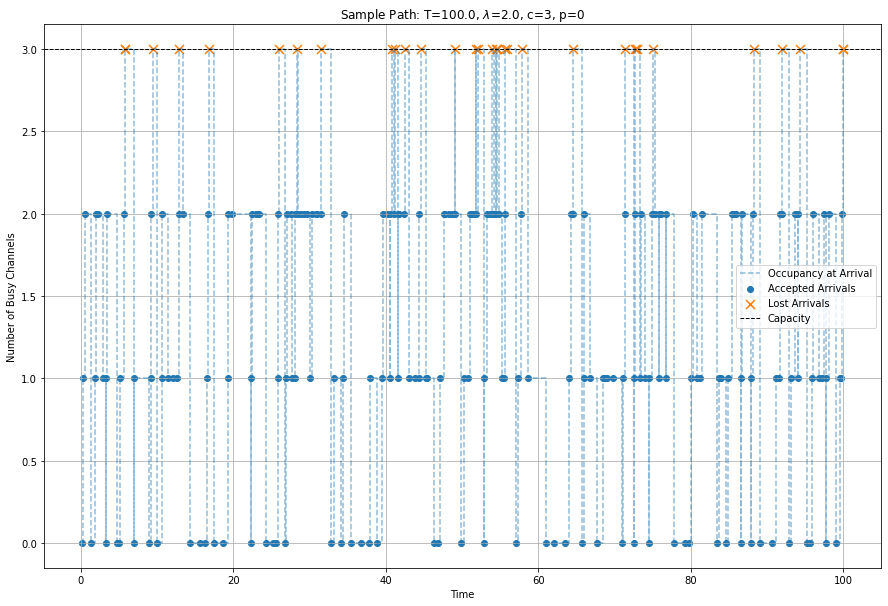



=== p=0.5 ===


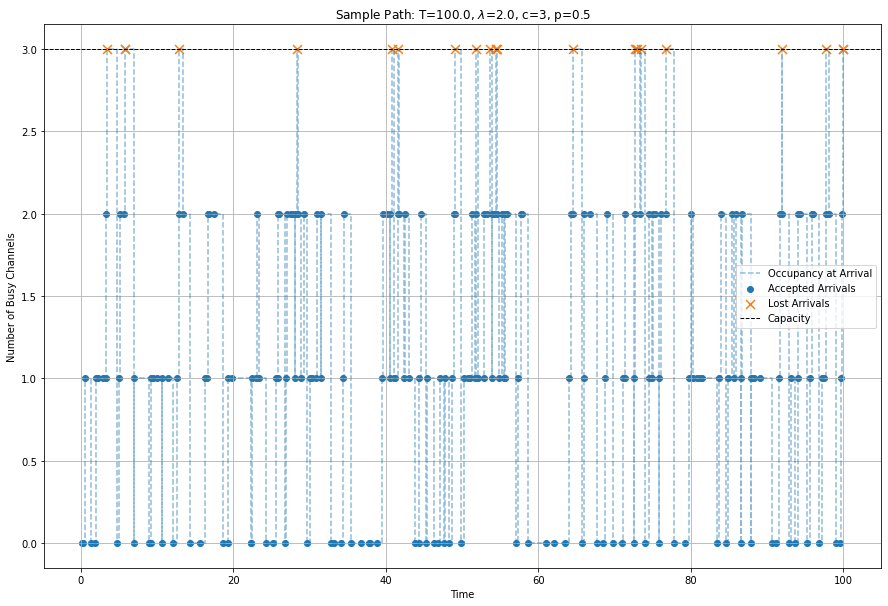



=== p=1.0 ===


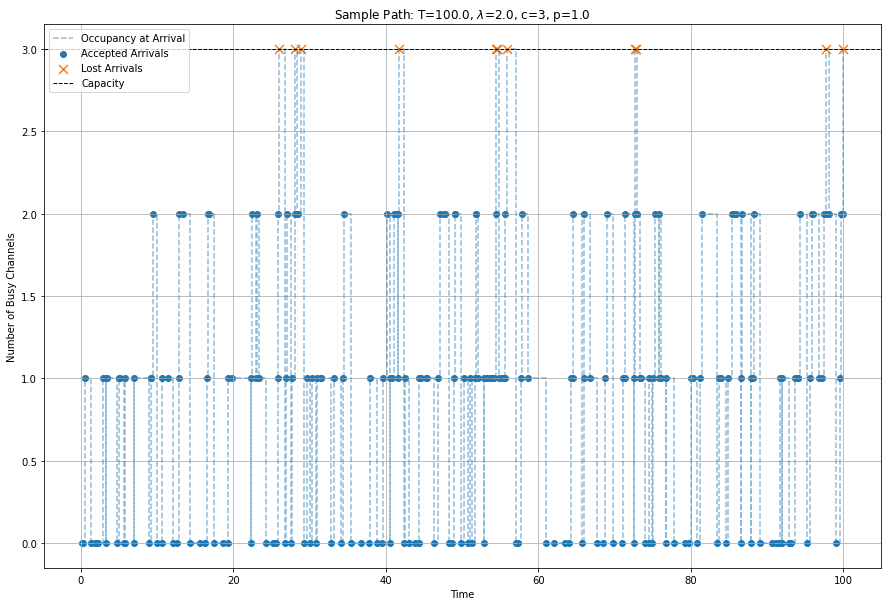

In [4]:
# simulate one path of M/G/3/3 loss system
def simulate_project_mail(T=100.0, lam=2.0, c=3, p=0.5, seed=1337, plot=False):
    """
    Simulate M/G/3/3 loss system over [0,T].
    Args:
    -----
        T (float): time horizon
        lam (float): arrival rate
        c (int): number of channels
        p (float): probability of good weather at an arrival
        seed (int): RNG seed
        plot (bool): flag to plot path
    Returns:
    --------
        out (dict): path summary
    """
    # set seed
    rng = np.random.default_rng(seed)

    # generate arrivals following PP(lambda)
    t = 0.0
    arrivals = []
    while True:
        t = t + rng.exponential(scale=1.0 / lam)
        if t > T:
            break
        arrivals.append(t)

    # store as array
    arrivals = np.array(arrivals)
    n_arr = len(arrivals)

    # each accepted job occupies one channel until departure
    departure_times = []

    # track results
    n_lost = 0
    n_accepted = 0
    weather_list = []
    service_list = []
    occupancy_at_arrival = []
    lost_indicator = []

    # loop over arrivals
    for t in arrivals:
        
        # clear completed services
        departure_times = [d for d in departure_times if d > t]

        # track occupancy seen by arrival
        n_busy = len(departure_times)
        occupancy_at_arrival.append(n_busy)

        # Bernoulli draw for weather (1 = good, 0 = bad)
        weather = rng.binomial(1, p)
        weather_list.append(weather)

        # accept message if channel available
        if n_busy < c:
            """
            Sample service time based on weather at arrival.
            Good weather: F(x)=x, 0<x<1  => Uniform(0,1)
            Bad weather: F(x)=x^3, 0<x<1 => X = U^(1/3)
            """
            u = rng.uniform(0.0, 1.0)

            if weather == 1:
                s = u
            else:
                s = u**(1.0 / 3.0)

            # track results
            departure_times.append(t + s)
            n_accepted = n_accepted + 1
            service_list.append(s)
            lost_indicator.append(0)
            
        # otherwise lose message
        else:
            n_lost = n_lost + 1
            service_list.append(np.nan)
            lost_indicator.append(1)

    # convert lists to arrays
    occupancy_at_arrival = np.array(occupancy_at_arrival)
    weather_list = np.array(weather_list)
    service_list = np.array(service_list)
    lost_indicator = np.array(lost_indicator)

    # empirical fraction of messages lost and service time (E(X))
    loss_fraction = n_lost / n_arr if n_arr > 0 else np.nan
    mean_service_emp = np.nanmean(service_list) if n_accepted > 0 else np.nan


    # plot path
    if plot:

        plt.figure(figsize=(15,10))

        # step plot of occupancy at arrivals
        plt.step(arrivals, occupancy_at_arrival, where="post", label="Occupancy at Arrival", linestyle="--", alpha=0.5)

        # accepted arrivals
        plt.scatter(arrivals[lost_indicator == 0], occupancy_at_arrival[lost_indicator == 0], 
                    marker="o", label="Accepted Arrivals")

        # scatter lost arrivals
        plt.scatter(arrivals[lost_indicator == 1], occupancy_at_arrival[lost_indicator == 1],
                    marker="x", s=80, label="Lost Arrivals")

        # horizontal line for number of channels
        plt.axhline(c, linestyle="--", linewidth=1, label="Capacity", color="black")

        # polish and display
        plt.title(fr"Sample Path: T={T}, $\lambda$={lam}, c={c}, p={p}")
        plt.xlabel("Time")
        plt.ylabel("Number of Busy Channels")
        plt.legend()
        plt.grid()
        plt.show()

    # return dictionary of results
    out = {"T": T, "lambda": lam, "c": c, "p": p, "n_arrivals": n_arr,
           "n_accepted": n_accepted, "n_lost": n_lost, "loss_fraction": loss_fraction,
           "mean_service_emp": mean_service_emp, "arrivals": arrivals,
           "occupancy_at_arrival": occupancy_at_arrival, "weather": weather_list,
           "service_times": service_list, "lost_indicator": lost_indicator}
    return out

# test function
for p in [0,0.5,1.0]:
    print(f"=== p={p} ===")
    _ = simulate_project_mail(T=100.0, lam=2.0, c=3, p=p, seed=1337, plot=True)
    print("\n")

The plotted sample paths behave as expected. When p=0, corresponding to always bad weather, the system quickly reaches capacity (3) and the Xs indicate clusters of losses. The system tends to remain at full capacity, causing multiple consecutive losses. When p=0.5, corresponding to mixed weather, there are fewer losses and they are less clustered than the p=0 case. When p=1, always good weather, max capacity is uncommon, and losses are isolated. Message loss only occurs when arrivals tend to bunch up, but generally there isn't much congestion.

The simulation code works as intended. I next generate sampling distributions for each relevant quantity by repeatedly simulating paths, and computing empirical mean service time, fraction lost, and number of message lost for each. I use a box and whiskers plot to visualize the distribution of MC estimates. 

Note that empirical mean service time is mean conditional on message being accepted, but in this model service time is independent of system state, so it should be close to expected unconditional service time. 

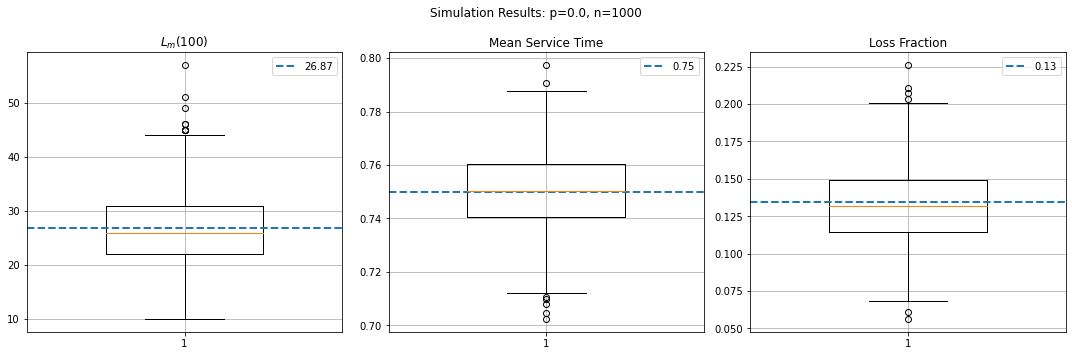

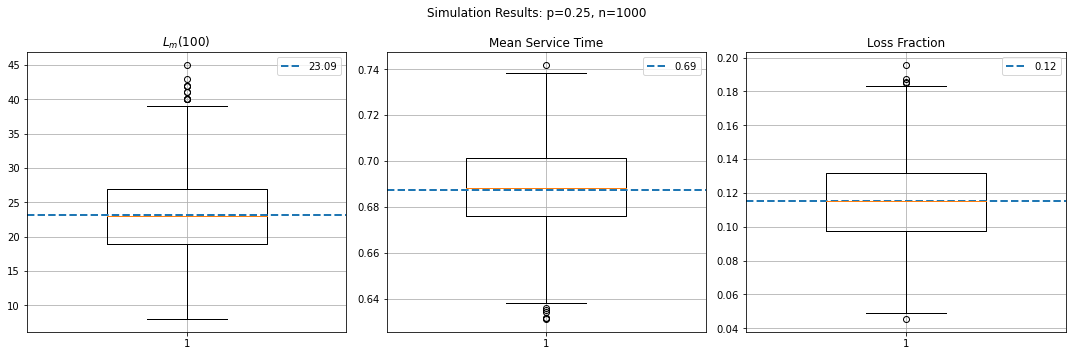

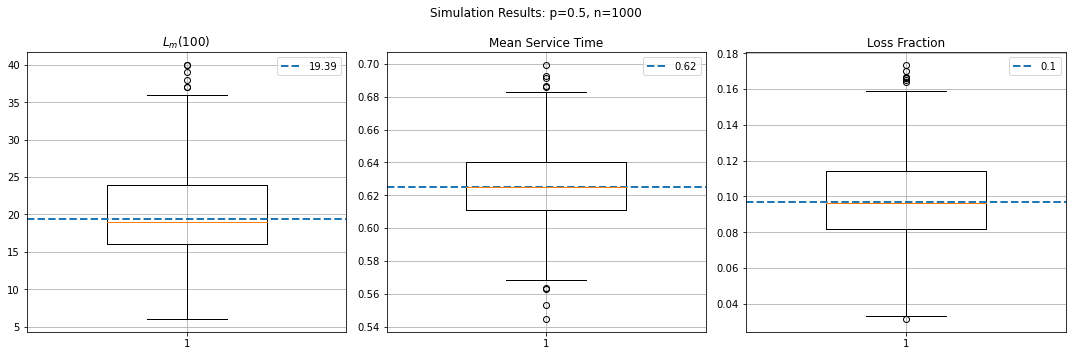

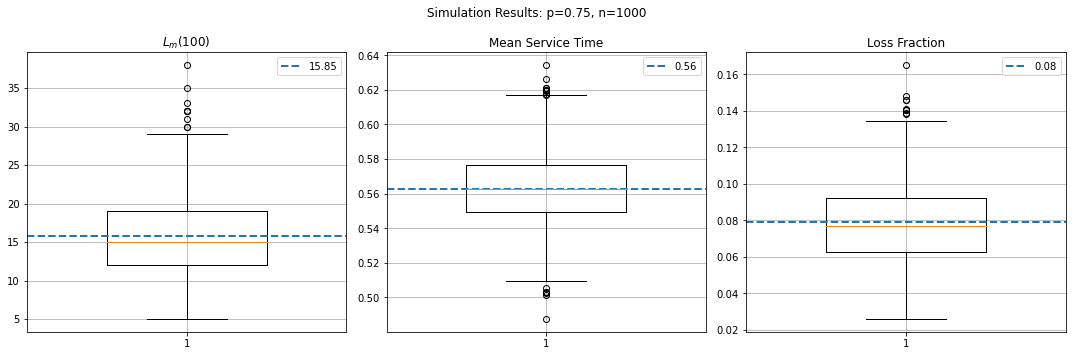

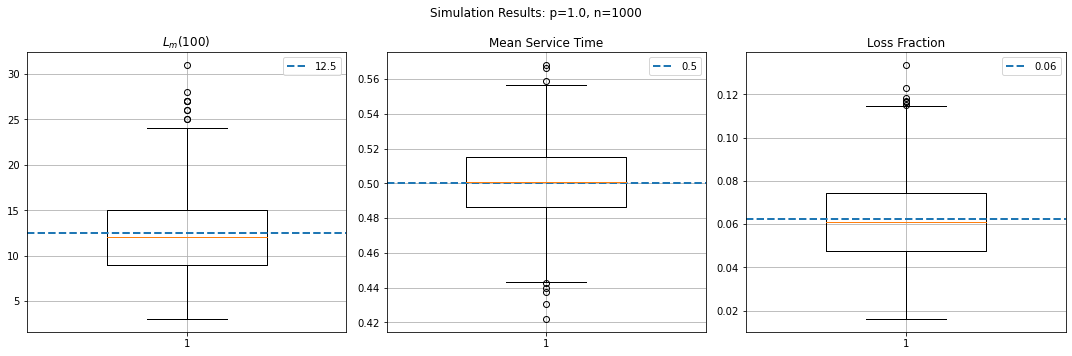

In [5]:
# track results 
rows = []

# primary cases
p_sgrid = [0.0, 0.25, 0.5, 0.75, 1.0]
n_sim = 1000

# base rng for independent seeds
rng = np.random.default_rng(1337)

# loop over primary cases
for p in p_sgrid:

    # simulate 1000 paths
    for rep in range(n_sim):
        sim_dict = simulate_project_mail(T=100.0, lam=2.0, c=3, p=p,
                                         seed=int(rng.integers(1, 10**9)),
                                         plot=False)

        # record results
        rows.append({"p": p, "rep": rep + 1, "n_lost": sim_dict["n_lost"], 
                     "mean_service_emp": sim_dict["mean_service_emp"],
                     "loss_fraction": sim_dict["loss_fraction"]})

# construct dataframe
sim_df = pd.DataFrame(rows)

# analytic values
exp_service = {p: (3 - p)/4 for p in p_sgrid}
erlang_grid = {p: erlang_b(3, (3 - p)/2) for p in p_sgrid}
e_lmt_grid = {p: exp_lmt(p, lam=2, t=100) for p in p_sgrid}

# plot results per p
for p in p_sgrid:
    
    # subset results
    df_p = sim_df[sim_df["p"] == p]
    
    # 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(15,5))
    
    # plot number lost
    axs[0].boxplot(df_p["n_lost"].values, vert=True, widths=0.5)
    axs[0].axhline(e_lmt_grid[p], linestyle="--", linewidth=2, label=f"{np.round(e_lmt_grid[p],2)}")
    axs[0].set_title(r"$L_m(100)$")
    
    # plot service time
    axs[1].boxplot(df_p["mean_service_emp"].values, vert=True, widths=0.5)
    axs[1].axhline(exp_service[p], linestyle="--", linewidth=2, label=f"{np.round(exp_service[p],2)}")
    axs[1].set_title("Mean Service Time")
    
    # plot loss fraction
    axs[2].boxplot(df_p["loss_fraction"].values, vert=True, widths=0.5)
    axs[2].axhline(erlang_grid[p], linestyle="--", linewidth=2, label=f"{np.round(erlang_grid[p],2)}")
    axs[2].set_title("Loss Fraction")
    
    # grid and legend
    for i in range(len(axs)):
        axs[i].legend()
        axs[i].grid()
    

    # set title and display
    fig.suptitle(f"Simulation Results: p={p}, n={n_sim}")
    plt.tight_layout()
    plt.show()

I note the following. 

1. Across all p values, the mean service time is accurate. Boxplots are tightly centered, and the median of the empirical distribution matches the theoretical value exactly. The service time generator is working. Variance compresses as p goes to 1, which is sensible because p = 1 is the case of purely uniform draws for service time. 

2. The empirical loss fraction is very close to the theoretical Erlang-B value (probability of lost message). Dashed lines are close to center of IQR, and empirically the loss fraction decrease smoothly as p approaches 1. This is consistent with the analytic curve from above. The result I found in the cited papers (insensitivity), that M/G/3/3 and M/M/3/3 are stochastically equivalent, is accurate. 

3. The number of lost messages is a scaled version of the loss fraction result. The spread increases with the mean, and variance is increasing in p, so as weather gets worse, service times grow, there is more congestion, system is at capacity more often, and blocking events are more variable. 

4. I don't see any clear evidence of bias in the estimates. There is some MC sampling noise, but overall variance is low. 

My conclusion is that the simulation exercise produces empirical results entirely consistent with the analytic results derived earlier. 

Check simulation results. The sampling distribution gives more detail than the analytic results. 

In [6]:
# groupby probability
g = sim_df.groupby("p")[["n_lost", "mean_service_emp", "loss_fraction"]].describe().T

# dictionary to map 
theory_map = {"n_lost": e_lmt_grid, "mean_service_emp": exp_service, "loss_fraction": erlang_grid}

# insert rows
pieces = []
for var in g.index.get_level_values(0).unique():
    
    # copy block of results
    block = g.loc[var].copy()
    
    # construct new df or theoretical results
    theory_row = pd.DataFrame([theory_map[var]], index=["theory"], columns=block.columns)
    
    # concatenate
    block = pd.concat([block, theory_row], axis=0)
    pieces.append(block)

# construct new df
out = pd.concat(pieces, keys=g.index.get_level_values(0).unique())
display(out)

p                               0.00         0.25         0.50         0.75  \
n_lost           count   1000.000000  1000.000000  1000.000000  1000.000000   
                 mean      26.691000    23.184000    19.791000    15.721000   
                 std        6.765300     6.066543     5.578211     5.007418   
                 min       10.000000     8.000000     6.000000     5.000000   
                 25%       22.000000    19.000000    16.000000    12.000000   
                 50%       26.000000    23.000000    19.000000    15.000000   
                 75%       31.000000    27.000000    24.000000    19.000000   
                 max       57.000000    45.000000    40.000000    38.000000   
                 theory    26.865672    23.085595    19.394880    15.846104   
mean_service_emp count   1000.000000  1000.000000  1000.000000  1000.000000   
                 mean       0.750189     0.688340     0.625678     0.563148   
                 std        0.014758     0.018870     0.020954     0.021117   
                 min        0.702383     0.631164     0.544556     0.487473   
                 25%        0.740675     0.675983     0.611241     0.549670   
                 50%        0.750183     0.688288     0.625133     0.562621   
                 75%        0.760409     0.701162     0.640279     0.576573   
                 max        0.797427     0.741828     0.699390     0.634422   
                 theory     0.750000     0.687500     0.625000     0.562500   
loss_fraction    count   1000.000000  1000.000000  1000.000000  1000.000000   
                 mean       0.132108     0.114880     0.097851     0.078079   
                 std        0.026536     0.024774     0.023463     0.021803   
                 min        0.056180     0.045455     0.031414     0.025907   
                 25%        0.114583     0.097297     0.081522     0.062500   
                 50%        0.131924     0.115385     0.096447     0.076923   
                 75%        0.149533     0.131707     0.114065     0.092323   
                 max        0.226190     0.195652     0.173516     0.165217   
                 theory     0.134328     0.115428     0.096974     0.079231   

p                               1.00  
n_lost           count   1000.000000  
                 mean      12.546000  
                 std        4.502239  
                 min        3.000000  
                 25%        9.000000  
                 50%       12.000000  
                 75%       15.000000  
                 max       31.000000  
                 theory    12.500000  
mean_service_emp count   1000.000000  
                 mean       0.500391  
                 std        0.021631  
                 min        0.421836  
                 25%        0.486334  
                 50%        0.500944  
                 75%        0.515358  
                 max        0.568138  
                 theory     0.500000  
loss_fraction    count   1000.000000  
                 mean       0.061900  
                 std        0.019825  
                 min        0.016043  
                 25%        0.047619  
                 50%        0.060914  
                 75%        0.074578  
                 max        0.133621  
                 theory     0.062500

### References

https://www.sciencedirect.com/science/article/pii/S0166531602001906



A. Willig, A Short Introduction to Queueing Theory. Technical University Berlin, 1999.
https://www.cs.ucf.edu/~lboloni/Teaching/EEL6785_Fall2010/slides/QueueingTheory.
pdf

Queueing Theory. Wikipedia.
https://en.wikipedia.org/wiki/Queueing_theory

R. Lockhart, Queueing Theory Lecture Notes. Simon Fraser University.
https://www.sfu.ca/~lockhart/richard/870/11_2/lectures/Queuing/web.pdf

R. Jain, Introduction to Queueing Theory. Washington University in St. Louis.
https://www.cse.wustl.edu/~jain/queue/ftp/q_30iqt.pdf

S. M. Ross, Introduction to Probability Models, Academic Press.

M. Zukerman, Introduction to Queueing Theory and Stochastic Teletraffic Models.
https://arxiv.org/abs/1307.2968

https://scholarworks.indianapolis.iu.edu/server/api/core/bitstreams/2be23fcc-20b0-4e59-ba65-7ae4d77ec8af/content

https://www.sciencedirect.com/science/article/abs/pii/S0166531617300354

https://dn720004.ca.archive.org/0/items/solution-of-some-problems-in-the-theory-of-probabilities-of-significance-in-auto/Solution%20of%20some%20problems%20in%20the%20theory%20of%20probabilities%20of%20significance%20in%20automatic%20telephones%20exchanges%20POEEJ_text.pdf

https://www.est.ufmg.br/ftp/fcruz/publics/cba04.pdf

Cheah, J. and MacGregor Smith, J. (1994). Generalized M/G/C/C state dependent queueing models and pedestrian traffic flows, Queueing Systems 15: 365–386.

https://onlinelibrary.wiley.com/doi/pdf/10.1002/9780470758946.app1?msockid=1c5ce0b9b06f6add29faf2d1b1e06b80